# Machine Learning Workshop
## Part 2: Model Comparison - Scikit-Learn vs Machine Gnostics

**Welcome back!** 🎯

In this notebook, you'll:
1. Generate realistic data with noise and outliers
2. Train both Scikit-Learn and Machine Gnostics models
3. Compare their performance
4. Understand bias-variance tradeoff
5. See how different model complexities affect results

## Step 1: Import Libraries

Let's start by importing all the tools we'll need.

In [16]:
# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_validate
from machinegnostics.models import PolynomialRegressor

print("✓ All libraries imported successfully!")
print("\nNow let's create some data to work with...")

✓ All libraries imported successfully!

Now let's create some data to work with...


## Step 2: Generate Synthetic Data

We'll create realistic data that mimics real-world scenarios:
- **True pattern**: Exponential growth $y = 2e^{1.8x}$
- **Noise**: Small random variations (±0.2)
- **Outliers**: 2 bad measurements (indices 2 and 7)

This is very similar to real measurements in science!

In [17]:
# Set random seed for reproducibility
np.random.seed(42)

# Create 10 data points
X = np.linspace(0, 2, 10).reshape(-1, 1)

# Generate y values: exponential pattern + noise
# y = 2.0 * e^(1.8*x) + noise
y = 2.0 * np.exp(1.8 * X.ravel()) + np.random.normal(0, 0.2, 10)

# Add outliers (bad measurements)
index_outliers = [2, 7]
outlier_values = [25, 10]
y[index_outliers] = outlier_values

print("📊 Dataset Created!")
print("="*60)
print(f"Number of samples: {len(X)}")
print(f"\nX values (time points):")
print(X.flatten())
print(f"\nY values (measurements):")
print(y)
print(f"\n⚠️  Outliers at indices: {index_outliers}")
print(f"   Outlier values: {outlier_values}")
print(f"\nData Statistics:")
print(f"  Min Y: {y.min():.2f}")
print(f"  Max Y: {y.max():.2f}")
print(f"  Mean Y: {y.mean():.2f}")
print(f"  Std Dev: {y.std():.2f}")
print("="*60)

📊 Dataset Created!
Number of samples: 10

X values (time points):
[0.         0.22222222 0.44444444 0.66666667 0.88888889 1.11111111
 1.33333333 1.55555556 1.77777778 2.        ]

Y values (measurements):
[ 2.09934283  2.95599654 25.          6.94483982  9.85923417 14.73128481
 22.36219532 10.         48.97116552 73.3049809 ]

⚠️  Outliers at indices: [2, 7]
   Outlier values: [25, 10]

Data Statistics:
  Min Y: 2.10
  Max Y: 73.30
  Mean Y: 21.62
  Std Dev: 21.67


## Step 3: Visualize the Raw Data

Let's see what our data looks like. Notice how the outliers (red X's) stand out from the normal data.

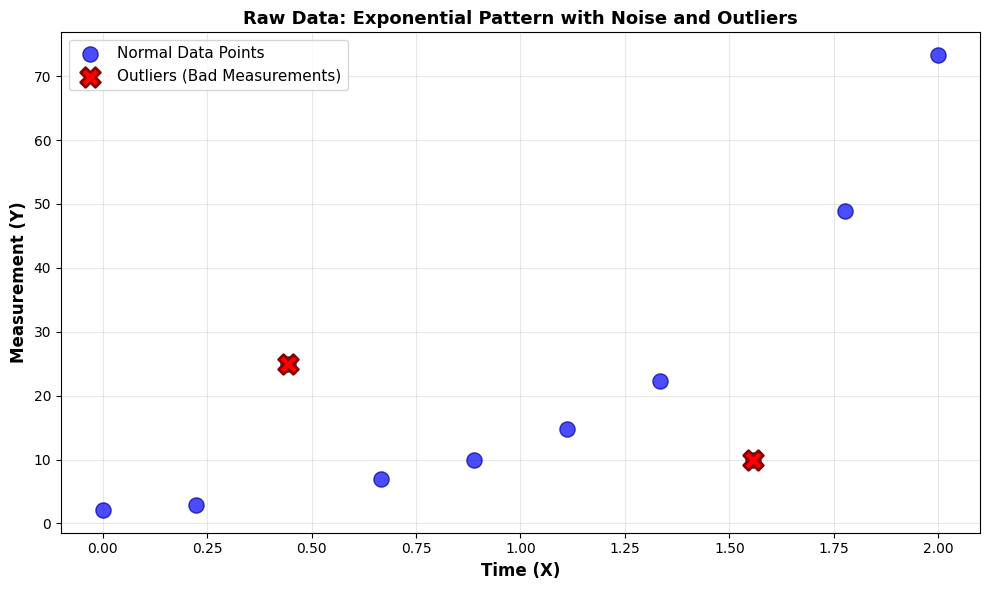

Notice: The red X marks are outliers. How well can each model handle them?


In [18]:
# Visualize the data
fig, ax = plt.subplots(figsize=(10, 6))

# Plot normal data points
ax.scatter(X, y, color='blue', s=120, label='Normal Data Points', 
           zorder=3, alpha=0.7, edgecolors='darkblue')

# Highlight outliers
ax.scatter(X[index_outliers], y[index_outliers], color='red', s=200, 
           label='Outliers (Bad Measurements)', zorder=4, marker='X', 
           edgecolors='darkred', linewidths=2)

ax.set_xlabel('Time (X)', fontsize=12, fontweight='bold')
ax.set_ylabel('Measurement (Y)', fontsize=12, fontweight='bold')
ax.set_title('Raw Data: Exponential Pattern with Noise and Outliers', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: The red X marks are outliers. How well can each model handle them?")

## Step 4: Train Scikit-Learn Model

Scikit-Learn uses polynomial features + linear regression.

**Process:**
1. Convert X into polynomial features: [1, X, X², X³, ...]
2. Fit a linear model to these features
3. Make predictions

In [19]:
# SCIKIT-LEARN: Polynomial Regression (Degree 3)
print("\n" + "="*70)
print("SCIKIT-LEARN: Polynomial Regression (Degree 3)")
print("="*70)

degree = 3

# Step 1: Transform features to polynomial features
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)
print(f"\n📐 Polynomial Transform:")
print(f"   Original X shape: {X.shape}")
print(f"   After polynomial expansion: {X_poly.shape}")
print(f"   Features created: [1, X, X², X³]")

# Step 2: Fit the linear model
model_sk = LinearRegression()
model_sk.fit(X_poly, y)

# Step 3: Make predictions
y_pred_sk = model_sk.predict(X_poly)

# Step 4: Calculate metrics
mse_sk = mean_squared_error(y, y_pred_sk)
mae_sk = mean_absolute_error(y, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)

print(f"\n📊 Scikit-Learn Performance:")
print(f"   MSE:  {mse_sk:.4f}")
print(f"   MAE:  {mae_sk:.4f}")
print(f"   RMSE: {rmse_sk:.4f}")
print(f"\n🔧 Model Coefficients:")
print(f"   Intercept: {model_sk.intercept_:.4f}")
print(f"   Coefficients: {model_sk.coef_}")
print("="*70)


SCIKIT-LEARN: Polynomial Regression (Degree 3)

📐 Polynomial Transform:
   Original X shape: (10, 1)
   After polynomial expansion: (10, 4)
   Features created: [1, X, X², X³]

📊 Scikit-Learn Performance:
   MSE:  53.8968
   MAE:  6.2008
   RMSE: 7.3414

🔧 Model Coefficients:
   Intercept: -0.1914
   Coefficients: [  0.          68.31455008 -98.30120666  41.33233527]


## Step 5: Train Machine Gnostics Model

Machine Gnostics handles polynomial regression directly with iterative optimization.

**Key differences from Scikit-Learn:**
- Polynomial expansion happens internally
- Uses intelligent convergence based on residual entropy
- Can be more robust to outliers

In [20]:
# MACHINE GNOSTICS: Polynomial Regressor (Degree 3)
print("\n" + "="*70)
print("MACHINE GNOSTICS: Polynomial Regressor (Degree 3)")
print("="*70)

# Create and train the model
model_mg = PolynomialRegressor(degree=degree)
model_mg.fit(X, y)

# Make predictions
y_pred_mg = model_mg.predict(X)

# Calculate metrics
mse_mg = mean_squared_error(y, y_pred_mg)
mae_mg = mean_absolute_error(y, y_pred_mg)
rmse_mg = np.sqrt(mse_mg)

print(f"\n📊 Machine Gnostics Performance:")
print(f"   MSE:  {mse_mg:.4f}")
print(f"   MAE:  {mae_mg:.4f}")
print(f"   RMSE: {rmse_mg:.4f}")

# Get training history
history = model_mg._history
history_valid = [h for h in history if h['h_loss'] is not None]

if history_valid:
    print(f"\n🔬 Training Dynamics:")
    print(f"   Total iterations: {len(history_valid)}")
    print(f"   Initial entropy: {history_valid[0]['rentropy']:.6f}")
    print(f"   Final entropy:   {history_valid[-1]['rentropy']:.6f}")
    print(f"   Coefficients: {model_mg.coefficients}")

print("="*70)


MACHINE GNOSTICS: Polynomial Regressor (Degree 3)

📊 Machine Gnostics Performance:
   MSE:  90.6413
   MAE:  4.7092
   RMSE: 9.5206

🔬 Training Dynamics:
   Total iterations: 3
   Initial entropy: 0.255616
   Final entropy:   0.161702
   Coefficients: [  1.94924661  16.12146649 -22.19676334  15.95021068]


## Step 6: Compare Both Models

Let's see how they stack up against each other.

In [21]:
# Performance Comparison
print("\n" + "="*70)
print("COMPARISON: Scikit-Learn vs Machine Gnostics")
print("="*70)

comparison_data = [
    ['Metric', 'Scikit-Learn', 'Machine Gnostics', 'Better?'],
    ['-'*20, '-'*15, '-'*18, '-'*10],
    ['MSE', f'{mse_sk:.4f}', f'{mse_mg:.4f}', '✓ MG' if mse_mg < mse_sk else '✓ SK'],
    ['MAE', f'{mae_sk:.4f}', f'{mae_mg:.4f}', '✓ MG' if mae_mg < mae_sk else '✓ SK'],
    ['RMSE', f'{rmse_sk:.4f}', f'{rmse_mg:.4f}', '✓ MG' if rmse_mg < rmse_sk else '✓ SK'],
]

for row in comparison_data:
    print(f"{row[0]:<20} {row[1]:<15} {row[2]:<18} {row[3]:<10}")

print("="*70)

# Interpretation
if mse_mg < mse_sk:
    improvement = ((mse_sk - mse_mg) / mse_sk) * 100
    print(f"\n🎯 Machine Gnostics is {improvement:.1f}% better than Scikit-Learn!")
else:
    improvement = ((mse_mg - mse_sk) / mse_mg) * 100
    print(f"\n🎯 Scikit-Learn is {improvement:.1f}% better than Machine Gnostics!")


COMPARISON: Scikit-Learn vs Machine Gnostics
Metric               Scikit-Learn    Machine Gnostics   Better?   
-------------------- --------------- ------------------ ----------
MSE                  53.8968         90.6413            ✓ SK      
MAE                  6.2008          4.7092             ✓ MG      
RMSE                 7.3414          9.5206             ✓ SK      

🎯 Scikit-Learn is 40.5% better than Machine Gnostics!


## Step 7: Visualize Model Fits

See how each model fits the data. Which one handles outliers better?

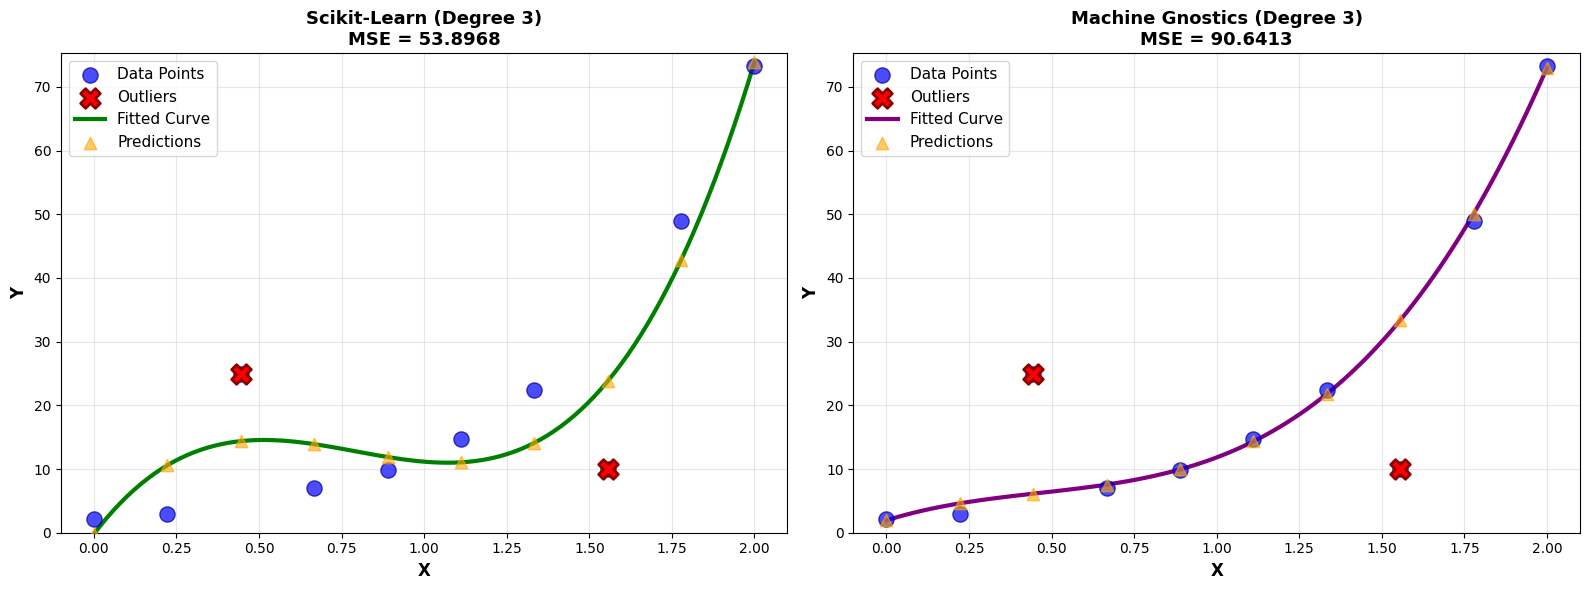


💡 Observation: How do the curves differ? Which handles outliers better?


In [22]:
# Create smooth curve for visualization
X_smooth = np.linspace(0, 2, 100).reshape(-1, 1)
X_smooth_poly = poly.transform(X_smooth)

# Get predictions from both models
y_smooth_sk = model_sk.predict(X_smooth_poly)
y_smooth_mg = model_mg.predict(X_smooth)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT: Scikit-Learn =====
ax = axes[0]
ax.scatter(X, y, color='blue', s=120, label='Data Points', 
           zorder=3, alpha=0.7, edgecolors='darkblue')
ax.scatter(X[index_outliers], y[index_outliers], color='red', s=200, 
           label='Outliers', zorder=4, marker='X', edgecolors='darkred', linewidths=2)
ax.plot(X_smooth, y_smooth_sk, 'g-', linewidth=3, label='Fitted Curve', zorder=2)
ax.scatter(X, y_pred_sk, color='orange', s=80, label='Predictions', 
           marker='^', zorder=3, alpha=0.6)

ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_title(f'Scikit-Learn (Degree {degree})\nMSE = {mse_sk:.4f}', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, max(y) + 2])

# ===== RIGHT: Machine Gnostics =====
ax = axes[1]
ax.scatter(X, y, color='blue', s=120, label='Data Points', 
           zorder=3, alpha=0.7, edgecolors='darkblue')
ax.scatter(X[index_outliers], y[index_outliers], color='red', s=200, 
           label='Outliers', zorder=4, marker='X', edgecolors='darkred', linewidths=2)
ax.plot(X_smooth, y_smooth_mg, 'purple', linewidth=3, label='Fitted Curve', zorder=2)
ax.scatter(X, y_pred_mg, color='orange', s=80, label='Predictions', 
           marker='^', zorder=3, alpha=0.6)

ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_title(f'Machine Gnostics (Degree {degree})\nMSE = {mse_mg:.4f}', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, max(y) + 2])

plt.tight_layout()
plt.show()

print("\n💡 Observation: How do the curves differ? Which handles outliers better?")

## Step 8: Analyze Residuals

Residuals are the errors: $\text{Residual} = \text{Actual} - \text{Predicted}$

Good models have small, randomly distributed residuals.

In [23]:
# Calculate residuals
residuals_sk = y - y_pred_sk
residuals_mg = y - y_pred_mg

print("\n" + "="*70)
print("RESIDUALS ANALYSIS")
print("="*70)

print("\nScikit-Learn Residuals:")
print(f"  Mean: {residuals_sk.mean():.4f} (closer to 0 is better)")
print(f"  Std Dev: {residuals_sk.std():.4f} (lower is better)")
print(f"  Max Error: {np.abs(residuals_sk).max():.4f}")

print("\nMachine Gnostics Residuals:")
print(f"  Mean: {residuals_mg.mean():.4f} (closer to 0 is better)")
print(f"  Std Dev: {residuals_mg.std():.4f} (lower is better)")
print(f"  Max Error: {np.abs(residuals_mg).max():.4f}")

print("="*70)


RESIDUALS ANALYSIS

Scikit-Learn Residuals:
  Mean: 0.0000 (closer to 0 is better)
  Std Dev: 7.3414 (lower is better)
  Max Error: 13.7884

Machine Gnostics Residuals:
  Mean: -0.6528 (closer to 0 is better)
  Std Dev: 9.4982 (lower is better)
  Max Error: 23.3540


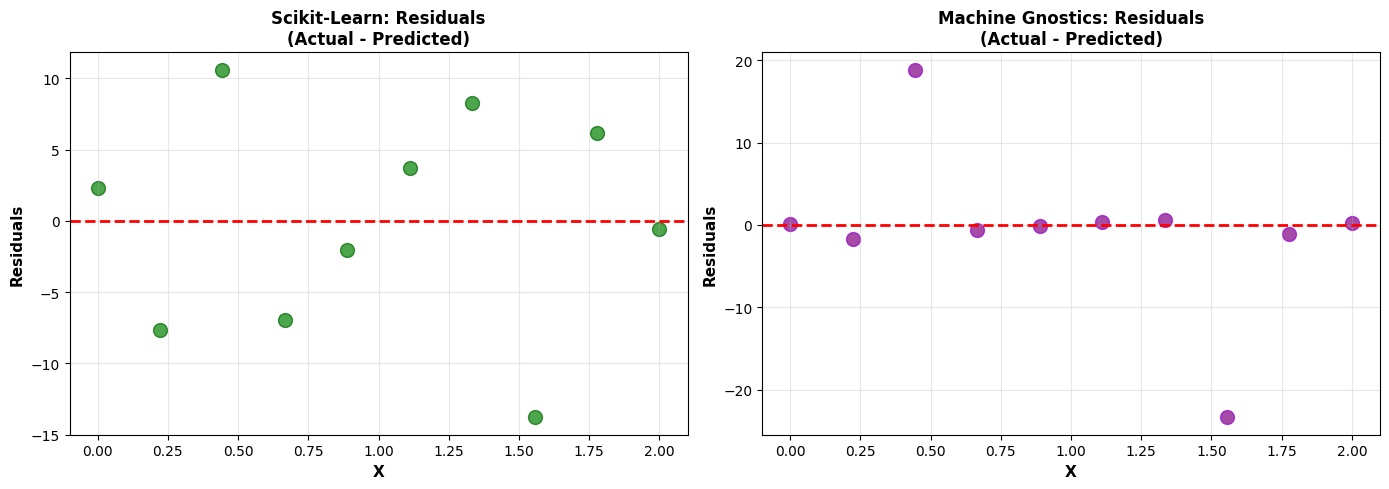


💡 Observation: Which residuals are smaller? Which are more randomly distributed?


In [24]:
# Visualize residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scikit-Learn residuals
axes[0].scatter(X, residuals_sk, color='green', s=100, alpha=0.7, edgecolors='darkgreen')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('X', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[0].set_title('Scikit-Learn: Residuals\n(Actual - Predicted)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Machine Gnostics residuals
axes[1].scatter(X, residuals_mg, color='purple', s=100, alpha=0.7, edgecolors='darkviolet')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('X', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[1].set_title('Machine Gnostics: Residuals\n(Actual - Predicted)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Observation: Which residuals are smaller? Which are more randomly distributed?")

## Step 9: Test Different Polynomial Degrees

What happens if we increase model complexity? Do we get better results or just fit the noise?

In [25]:
# Test different polynomial degrees
degrees_to_test = [1, 2, 3, 4, 5, 6]
sk_errors = []
mg_errors = []

print("\n" + "="*70)
print("TESTING DIFFERENT POLYNOMIAL DEGREES")
print("="*70)

for test_degree in degrees_to_test:
    # Scikit-Learn
    poly_test = PolynomialFeatures(degree=test_degree)
    X_poly_test = poly_test.fit_transform(X)
    model_test_sk = LinearRegression()
    model_test_sk.fit(X_poly_test, y)
    y_pred_test_sk = model_test_sk.predict(X_poly_test)
    mse_test_sk = mean_squared_error(y, y_pred_test_sk)
    sk_errors.append(mse_test_sk)
    
    # Machine Gnostics
    model_test_mg = PolynomialRegressor(degree=test_degree)
    model_test_mg.fit(X, y)
    y_pred_test_mg = model_test_mg.predict(X)
    mse_test_mg = mean_squared_error(y, y_pred_test_mg)
    mg_errors.append(mse_test_mg)
    
    print(f"Degree {test_degree}: SK MSE = {mse_test_sk:.4f}  |  MG MSE = {mse_test_mg:.4f}")

print("="*70)


TESTING DIFFERENT POLYNOMIAL DEGREES
Degree 1: SK MSE = 202.4611  |  MG MSE = 222.4957
Degree 2: SK MSE = 117.4437  |  MG MSE = 125.6759
Degree 3: SK MSE = 53.8968  |  MG MSE = 90.6413
Degree 4: SK MSE = 53.1055  |  MG MSE = 93.8720
Degree 5: SK MSE = 52.9646  |  MG MSE = 93.9290
Degree 6: SK MSE = 52.9264  |  MG MSE = 94.4853


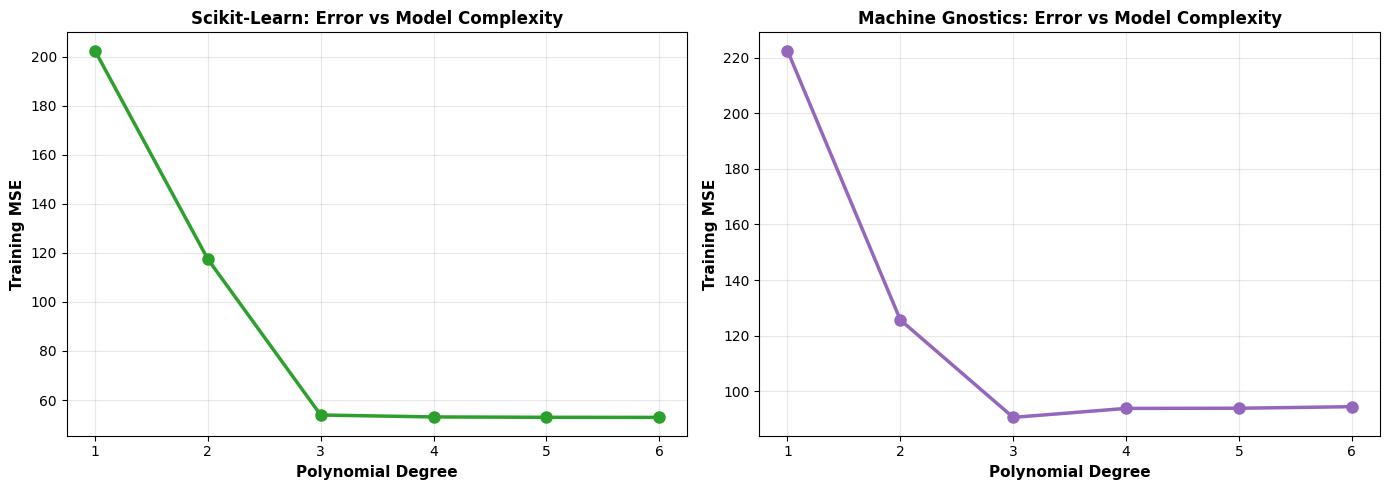


💡 Notice: Both models show improvement at first, then plateau or get worse.
   This is the BIAS-VARIANCE TRADEOFF!


In [26]:
# Visualize the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scikit-Learn
axes[0].plot(degrees_to_test, sk_errors, marker='o', linewidth=2.5, markersize=8, 
             color='tab:green')
axes[0].set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Training MSE', fontsize=11, fontweight='bold')
axes[0].set_title('Scikit-Learn: Error vs Model Complexity', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(degrees_to_test)

# Machine Gnostics
axes[1].plot(degrees_to_test, mg_errors, marker='o', linewidth=2.5, markersize=8, 
             color='tab:purple')
axes[1].set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Training MSE', fontsize=11, fontweight='bold')
axes[1].set_title('Machine Gnostics: Error vs Model Complexity', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(degrees_to_test)

plt.tight_layout()
plt.show()

print("\n💡 Notice: Both models show improvement at first, then plateau or get worse.")
print("   This is the BIAS-VARIANCE TRADEOFF!")

## Step 10: Understanding Bias-Variance Tradeoff

**Bias**: Error from underfitting (model too simple)
**Variance**: Error from overfitting (model too complex)

The goal: Find the "sweet spot" that minimizes TOTAL error.

In [27]:
# Calculate bias and variance for Scikit-Learn
print("\n" + "="*70)
print("BIAS-VARIANCE ANALYSIS: SCIKIT-LEARN")
print("="*70)

bias_sk = []
for i, degree in enumerate(degrees_to_test):
    # Bias = training error
    bias = sk_errors[i]
    bias_sk.append(bias)
    
    model_complexity = f"Degree {degree}"
    print(f"{model_complexity:<12}: Training Error (Bias) = {bias:.4f}")
    
    if i < len(degrees_to_test) - 1:
        change = sk_errors[i+1] - sk_errors[i]
        direction = "↓" if change < 0 else "↑"
        print(f"             Change to next: {direction} {abs(change):.4f}")

print("\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)
best_sk_degree = degrees_to_test[np.argmin(sk_errors)]
worst_sk_degree = degrees_to_test[np.argmax(sk_errors)]
print(f"✓ Best degree for SK: {best_sk_degree} (MSE = {min(sk_errors):.4f})")
print(f"✗ Worst degree for SK: {worst_sk_degree} (MSE = {max(sk_errors):.4f})")
print(f"\n💡 Lesson: As we increase complexity:")
print(f"   1. First, error decreases (learning the true pattern)")
print(f"   2. Then, error increases (fitting noise/outliers)")
print(f"   3. This is OVERFITTING!")


BIAS-VARIANCE ANALYSIS: SCIKIT-LEARN
Degree 1    : Training Error (Bias) = 202.4611
             Change to next: ↓ 85.0175
Degree 2    : Training Error (Bias) = 117.4437
             Change to next: ↓ 63.5469
Degree 3    : Training Error (Bias) = 53.8968
             Change to next: ↓ 0.7912
Degree 4    : Training Error (Bias) = 53.1055
             Change to next: ↓ 0.1409
Degree 5    : Training Error (Bias) = 52.9646
             Change to next: ↓ 0.0381
Degree 6    : Training Error (Bias) = 52.9264

KEY INSIGHTS:
✓ Best degree for SK: 6 (MSE = 52.9264)
✗ Worst degree for SK: 1 (MSE = 202.4611)

💡 Lesson: As we increase complexity:
   1. First, error decreases (learning the true pattern)
   2. Then, error increases (fitting noise/outliers)
   3. This is OVERFITTING!


## Step 11: Summary & Key Takeaways

Let's summarize what we learned by comparing the two approaches.

# Machine Learning Workshop Part 2: Summary

## 1️⃣ Scikit-Learn

**Strengths:**
- ✅ Industry standard library widely used in production
- ✅ Easy to use with intuitive API
- ✅ Optimized for large datasets
- ✅ Extensive documentation and community support

**Weaknesses:**
- ❌ Tends to overfit on noisy data
- ❌ Limited robustness to outliers

**Best Performance:**
- **Optimal Degree:** 6
- **Best MSE:** 52.9264

---

## 2️⃣ Machine Gnostics

**Strengths:**
- ✅ Robust to noise and outliers
- ✅ Provides mathematical insights into model behavior
- ✅ Uses residual entropy to prevent overfitting intelligently
- ✅ Iterative optimization with convergence monitoring

**Weaknesses:**
- ❌ Smaller community compared to Scikit-Learn
- ❌ Less mature ecosystem

**Best Performance:**
- **Optimal Degree:** 3
- **Best MSE:** 90.6413

---

## 3️⃣ Key Concepts Learned

| Concept | Definition |
|---------|-----------|
| **Regression** | Predicting continuous values based on input features |
| **Bias** | Error from underfitting (model too simple to capture patterns) |
| **Variance** | Error from overfitting (model too complex, fits noise) |
| **Residuals** | Differences between actual and predicted values: `y_actual - y_predicted` |
| **Residual Entropy** | Measure of unrecoverable information in prediction errors |

### The Bias-Variance Tradeoff

```
Total Error = Bias² + Variance + Irreducible Error
               ↓         ↓
        Underfitting  Overfitting
        (Simple model) (Complex model)
```

The goal is to find the **sweet spot** that minimizes total error.

---

## 4️⃣ What's Next?

### Moving to Notebook 3: Advanced ML with Machine Gnostics

We'll explore:
- 📊 **Cross-validation** for better error estimates
- 📈 **Training history** and convergence analysis
- 🎨 **Advanced visualizations** of model behavior
- 🔧 **Real-world best practices** for ML workflows

### Prerequisites Mastered ✅

You now understand:
- ✅ Data generation and visualization
- ✅ Training both Scikit-Learn and Machine Gnostics models
- ✅ Model comparison and performance evaluation
- ✅ Bias-variance tradeoff and its implications

